In [1]:
# lets import first
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
# sorting by date
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [6]:
# now lets create pivot table to create the graph
df.pivot_table(values='salary_year_avg', index='job_title_short', aggfunc='median')

,salary_year_avg
job_title_short,
Business Analyst,85000.0
Cloud Engineer,90000.0
Data Analyst,90000.0
Data Engineer,125000.0
Data Scientist,127500.0
Machine Learning Engineer,106415.0
Senior Data Analyst,111175.0
Senior Data Engineer,147500.0
Senior Data Scientist,155500.0


In [ ]:
# (by Group By)
df.groupby('job_title_short')['salary_year_avg'].median()
# to reduce the lines of codes we ue pivot tables 

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Data Engineer                125000.0
Data Scientist               127500.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Software Engineer             99150.0
Name: salary_year_avg, dtype: float64

In [9]:
# lets include some more metrics
df.pivot_table(values='salary_year_avg', index='job_title_short', aggfunc={'salary_year_avg':['median','max','min']})

,max,median,min
job_title_short,,,
Business Analyst,387460.0,85000.0,16500.0
Cloud Engineer,280000.0,90000.0,42000.0
Data Analyst,650000.0,90000.0,25000.0
Data Engineer,525000.0,125000.0,15000.0
Data Scientist,960000.0,127500.0,27000.0
Machine Learning Engineer,325000.0,106415.0,30000.0
Senior Data Analyst,425000.0,111175.0,30000.0
Senior Data Engineer,425000.0,147500.0,35000.0
Senior Data Scientist,890000.0,155500.0,45000.0


In [26]:
# now we will pivot to include different job title and countries
df_pivoted = df.pivot_table(values='salary_year_avg', index='job_country',columns='job_title_short', aggfunc='median').dropna(how = 'all')
df_pivoted

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'United States'),
  Text(1, 0, 'India'),
  Text(2, 0, 'United Kingdom'),
  Text(3, 0, 'France'),
  Text(4, 0, 'Germany')])

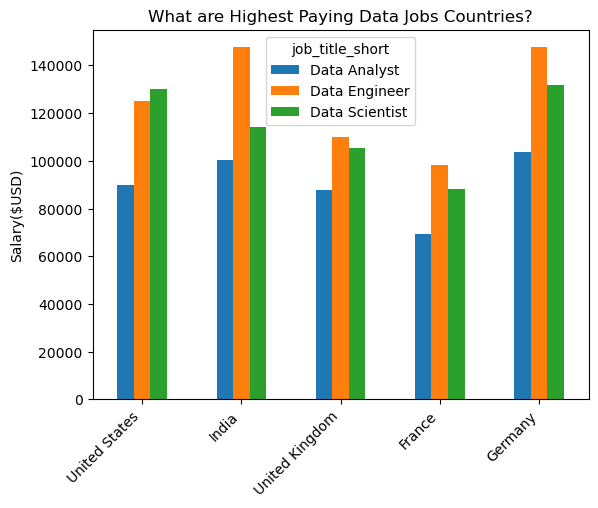

In [58]:
# now we will make a list of top 7 countries which provide jobs
top_countries = df['job_country'].value_counts().head(5).index

# now we will get column of median salary
df_pivoted = df_pivoted.loc[top_countries]

# now selecting job titles
job_titles = ['Data Analyst','Data Engineer','Data Scientist']
df_pivoted = df_pivoted[job_titles]

# now finally we can plot 
df_pivoted.plot(kind='bar')

# formatting
plt.ylabel('Salary($USD)')
plt.xlabel('')
plt.title('What are Highest Paying Data Jobs Countries?')
plt.xticks(rotation=45,ha='right')